In [2]:
print("test")

test


In [17]:
#Charger dataset
from datasets import load_dataset
import numpy as np

In [ ]:
ds = load_dataset("imdb") #the datasets library recognizes "imdb" as a predefined dataset.

In [9]:
ds
#Le dataset est composé de 3 parties : train et test, que nous utiliserons, et unsupervised que nous n’utiliserons pas.
#Chaque partie contient des exemples de critiques de films avec leur sentiment associé (positif ou négatif).

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [ ]:
train_df = ds['train'].to_pandas()
#to_pandas() pour convertir en Pandas DataFrame :
# facile à afficher, filtrer, analyser
# compatible avec beaucoup de libs (matplotlib, sklearn, etc.)

In [13]:
# train_df.head()
train_df.sample(5)

,text,label
16935,I really enjoyed the detail that went into the...,1
23081,"I work at a movie store, and as such, I am alw...",1
21661,"Purple Rain... what else can i say, the title ...",1
15365,"As a young boy, I always sort of hated ""Cinder...",1
21667,"This is NOT as bad a movie as some reviewers, ...",1


In [14]:
#vérifier si le dataset est équilibré:
train_df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

In [18]:
# train_df['sentiment'] = train_df['label'].map({0: 'negatif', 1: 'positif'})
train_df['sentiment'] = np.where(train_df['label']==1, "positif","negatif")

In [ ]:
train_df
#train_df['sentiment'] same as train_df.sentiment

,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negatif
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negatif
2,If only to avoid making this type of film in t...,0,negatif
3,This film was probably inspired by Godard's Ma...,0,negatif
4,"Oh, brother...after hearing about this ridicul...",0,negatif
...,...,...,...
24995,A hit at the time but now better categorised a...,1,positif
24996,I love this movie like no other. Another time ...,1,positif
24997,This film and it's sequel Barry Mckenzie holds...,1,positif
24998,'The Adventures Of Barry McKenzie' started lif...,1,positif


In [22]:
train_df.sentiment.value_counts()

sentiment
negatif    12500
positif    12500
Name: count, dtype: int64

<Axes: >

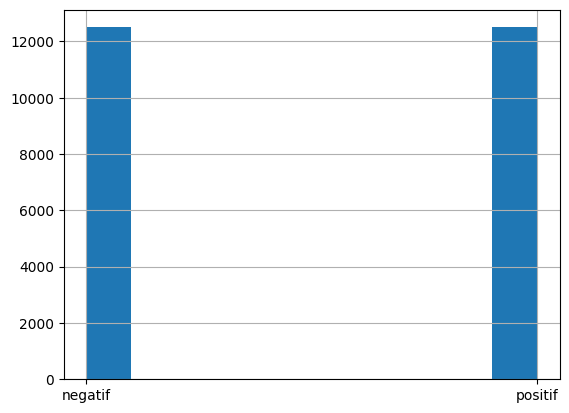

In [24]:
train_df.sentiment.hist()

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
examples_df, gold_examples_df = train_test_split(
    train_df, test_size=0.2, random_state=123
    #0.2 cad 20% examples rest gold_examples
)

In [27]:
examples_df.shape, gold_examples_df.shape

((20000, 3), (5000, 3))

In [ ]:
columns = ["text", "sentiment"]
gold_examples = (
                 gold_examples_df[columns]
                 .sample(20, random_state=34)
                 .to_json(orient="records")#Très pratique pour envoyer à un LLM/API.
                ) 